# Statement or Description of Chosen Project

This project investigates the reliability and comparative performance of machine learning algorithms in predicting consumer conversion and revenue potential across three diverse marketing datasets. By systematically applying multiple modeling approaches—K-Nearest Neighbors (KNN), Gradient Boosting, K-Means clustering, DBSCAN, and Hierarchical Agglomerative Clustering (HAC)—the project establishes a comprehensive methodology for evaluating both model performance and data quality. A key focus is understanding how hyperparameter tuning and distance metric selection influence predictive accuracy and clustering validity. The analysis addresses critical challenges in marketing analytics: distinguishing signal from noise in synthetic data, identifying which specific features drive conversion likelihood, and determining when data quality limitations constrain model expressiveness. Through rigorous evaluation using metrics such as accuracy, F1-score, R² score, silhouette scores, and Davies-Bouldin indices, the project demonstrates how algorithmic choice and parameter configuration directly impact business outcomes. High stakes exist when marketing leaders rely on unreliable predictions for budget allocation and customer targeting; therefore, this project provides a framework for iteratively validating data quality before and after modeling, ensuring that actionable insights extracted from data support sound strategic decisions.

# Week 11

In [2]:
import pandas as pd

### DBSCAN for predict_conversion_df

In [3]:
predict_conversion_df = pd.read_csv("digital_marketing_campaign_dataset.csv")
google_ads_df = pd.read_csv("GoogleAds_DataAnalytics_Sales_Uncleaned.csv")
marketing_product_df = pd.read_csv("marketing_and_product_performance.csv")

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select numeric columns for clustering (exclude CustomerID)
numeric_cols = predict_conversion_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_filtered = [col for col in numeric_cols if col != 'CustomerID']

# Prepare data: fill NaN values with mean
X = predict_conversion_df[numeric_cols_filtered].fillna(predict_conversion_df[numeric_cols_filtered].mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to dataframe
predict_conversion_df['DBSCAN_Cluster'] = clusters

# Display results
unique_clusters = set(clusters) - {-1}
n_noise = list(clusters).count(-1)

print("="*70)
print("DBSCAN CLUSTERING RESULTS")
print("="*70)
print(f"\nParameters: eps=2.0, min_samples=5")
print(f"Number of clusters: {len(unique_clusters)}")
print(f"Number of noise points: {n_noise} ({n_noise/len(clusters)*100:.1f}%)")
print(f"Number of clustered points: {len(clusters) - n_noise} ({(len(clusters) - n_noise)/len(clusters)*100:.1f}%)")

print(f"\nCluster distribution:")
print(pd.Series(clusters).value_counts().sort_index())

print(f"\nTop 15 largest clusters:")
cluster_sizes = pd.Series(clusters).value_counts().sort_values(ascending=False)
for i, (cluster_id, size) in enumerate(cluster_sizes.head(15).items(), 1):
    if cluster_id == -1:
        print(f"  {i:2}. NOISE: {size:4} points ({size/len(clusters)*100:5.1f}%)")
    else:
        print(f"  {i:2}. Cluster {cluster_id:3}: {size:4} points ({size/len(clusters)*100:5.1f}%)")

print(f"\nFirst 10 rows with cluster assignments:")
print(predict_conversion_df[['CustomerID', 'Age', 'Income', 'Conversion', 'DBSCAN_Cluster']].head(10))

print("\n" + "="*70)
print("CLUSTER STATISTICS")
print("="*70)
for cluster_id in sorted(unique_clusters)[:10]:  # Show first 10 clusters
    cluster_data = predict_conversion_df[predict_conversion_df['DBSCAN_Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print(f"  Avg Age: {cluster_data['Age'].mean():.1f} years")
    print(f"  Avg Income: ${cluster_data['Income'].mean():.0f}")
    print(f"  Avg AdSpend: ${cluster_data['AdSpend'].mean():.2f}")
    print(f"  Conversion Rate: {cluster_data['Conversion'].mean()*100:.1f}%")

c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\pandas\core\generic.py:7406: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k


DBSCAN CLUSTERING RESULTS

Parameters: eps=2.0, min_samples=5
Number of clusters: 119
Number of noise points: 6912 (86.4%)
Number of clustered points: 1088 (13.6%)

Cluster distribution:
-1      6912
 0       250
 1         6
 2        10
 3         6
        ... 
 114       4
 115       5
 116       4
 117       5
 118       4
Name: count, Length: 120, dtype: int64

Top 15 largest clusters:
   1. NOISE: 6912 points ( 86.4%)
   2. Cluster   0:  250 points (  3.1%)
   3. Cluster  14:   49 points (  0.6%)
   4. Cluster   4:   39 points (  0.5%)
   5. Cluster  23:   21 points (  0.3%)
   6. Cluster  64:   17 points (  0.2%)
   7. Cluster  45:   16 points (  0.2%)
   8. Cluster  12:   15 points (  0.2%)
   9. Cluster  49:   15 points (  0.2%)
  10. Cluster   6:   14 points (  0.2%)
  11. Cluster  90:   14 points (  0.2%)
  12. Cluster  30:   14 points (  0.2%)
  13. Cluster  42:   14 points (  0.2%)
  14. Cluster   8:   14 points (  0.2%)
  15. Cluster  97:   12 points (  0.1%)

First 10 r

### HAC for predict_conversion_df

HIERARCHICAL AGGLOMERATIVE CLUSTERING (HAC) - WARD LINKAGE


C:\Users\santo\AppData\Local\Temp\ipykernel_19720\918658600.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  predict_conversion_df['HAC_Ward_Cluster'] = hac_clusters



HAC with Ward Linkage applied successfully!
  • Number of clusters: 15
  • Total customers: 8000
  • No noise points (all customers assigned to a cluster)

CLUSTER SIZE DISTRIBUTION:
  • Min cluster size: 310
  • Max cluster size: 988
  • Mean cluster size: 533
  • Std of cluster size: 201

CLUSTER QUALITY METRICS:
  • Silhouette Score: 0.0053 (range: -1 to 1, higher is better)
  • Davies-Bouldin Index: 3.5125 (lower is better)
  • Calinski-Harabasz Score: 148.02 (higher is better)

CONVERSION ANALYSIS BY HAC CLUSTER:

Top 5 Clusters by Conversion Rate:
                  Conv_Count  Total_Customers  Conv_Rate  Avg_Age  Avg_Income  Avg_AdSpend  Avg_CTR
HAC_Ward_Cluster                                                                                   
0                        777              777        1.0    45.93    65908.41      6086.42     0.20
1                        567              567        1.0    47.18    84894.30      5940.79     0.19
2                        770           

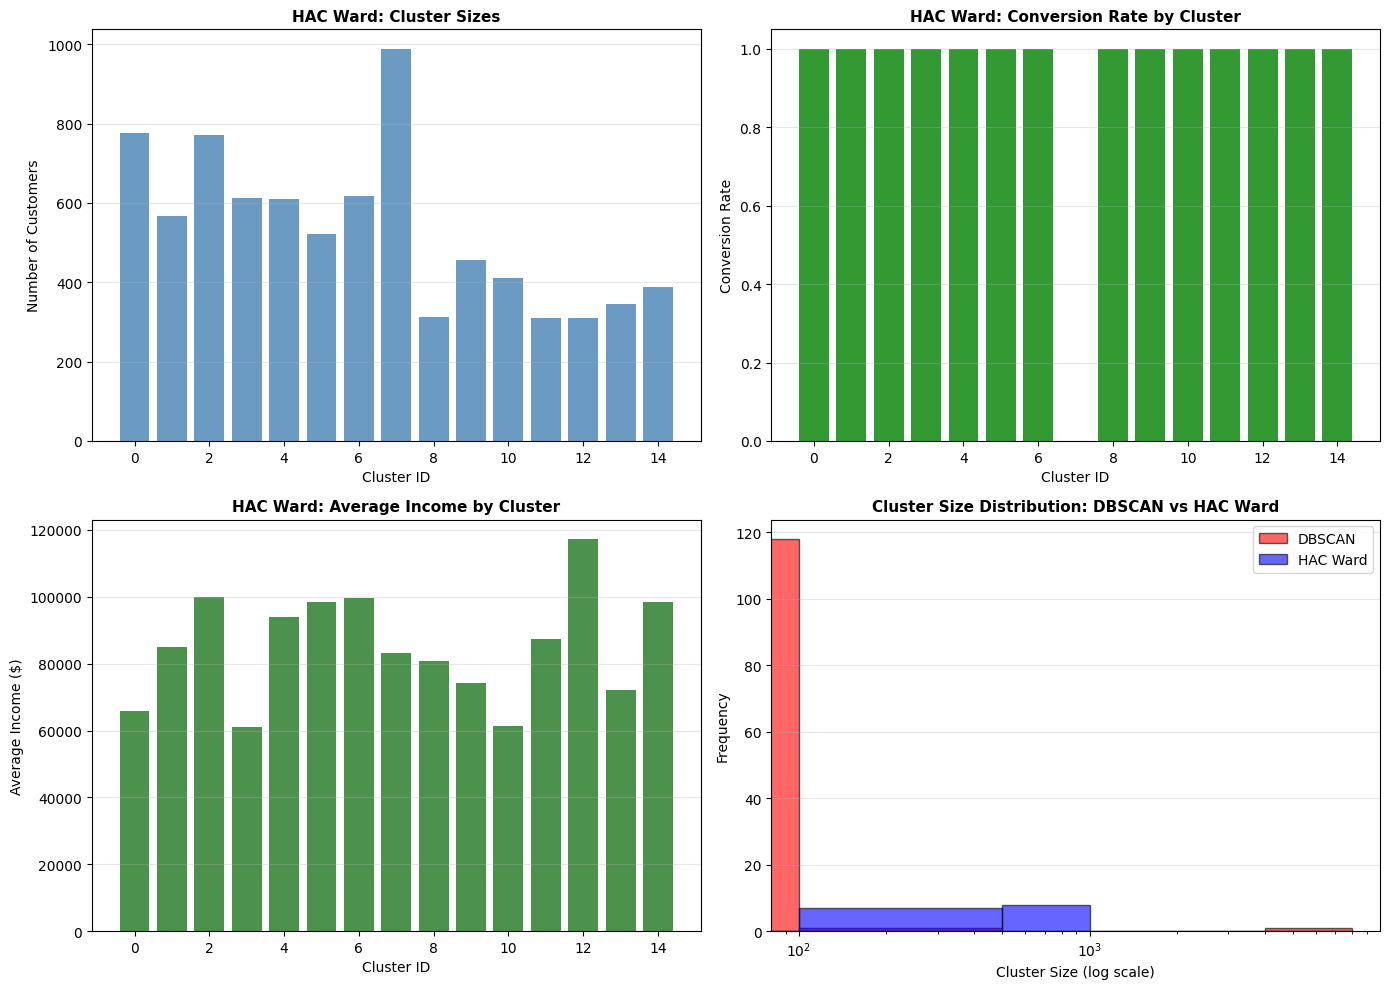

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage as hierarchy_linkage
from sklearn.cluster import AgglomerativeClustering

print("="*70)
print("HIERARCHICAL AGGLOMERATIVE CLUSTERING (HAC) - WARD LINKAGE")
print("="*70)

# Apply HAC with Ward linkage
n_clusters_hac = 15  # Using 15 clusters for comparison with previous analysis
hac_ward = AgglomerativeClustering(n_clusters=n_clusters_hac, linkage='ward')
hac_clusters = hac_ward.fit_predict(X_scaled)

# Add HAC clusters to dataframe
predict_conversion_df['HAC_Ward_Cluster'] = hac_clusters

print(f"\nHAC with Ward Linkage applied successfully!")
print(f"  • Number of clusters: {n_clusters_hac}")
print(f"  • Total customers: {len(hac_clusters)}")
print(f"  • No noise points (all customers assigned to a cluster)")

# Cluster statistics
cluster_sizes_hac = pd.Series(hac_clusters).value_counts().sort_index()
print(f"\nCLUSTER SIZE DISTRIBUTION:")
print(f"  • Min cluster size: {cluster_sizes_hac.min()}")
print(f"  • Max cluster size: {cluster_sizes_hac.max()}")
print(f"  • Mean cluster size: {cluster_sizes_hac.mean():.0f}")
print(f"  • Std of cluster size: {cluster_sizes_hac.std():.0f}")

# Quality metrics
silhouette_hac = silhouette_score(X_scaled, hac_clusters)
davies_bouldin_hac = davies_bouldin_score(X_scaled, hac_clusters)
calinski_hac = calinski_harabasz_score(X_scaled, hac_clusters)

print(f"\nCLUSTER QUALITY METRICS:")
print(f"  • Silhouette Score: {silhouette_hac:.4f} (range: -1 to 1, higher is better)")
print(f"  • Davies-Bouldin Index: {davies_bouldin_hac:.4f} (lower is better)")
print(f"  • Calinski-Harabasz Score: {calinski_hac:.2f} (higher is better)")

# Conversion rate analysis
print(f"\nCONVERSION ANALYSIS BY HAC CLUSTER:")
hac_conversion = predict_conversion_df.groupby('HAC_Ward_Cluster').agg({
    'Conversion': ['sum', 'count', 'mean'],
    'Age': 'mean',
    'Income': 'mean',
    'AdSpend': 'mean',
    'ClickThroughRate': 'mean'
}).round(2)

hac_conversion.columns = ['Conv_Count', 'Total_Customers', 'Conv_Rate', 'Avg_Age', 'Avg_Income', 'Avg_AdSpend', 'Avg_CTR']
hac_conversion = hac_conversion.sort_values('Conv_Rate', ascending=False)

print("\nTop 5 Clusters by Conversion Rate:")
print(hac_conversion.head().to_string())

# Visualization: Dendrogram preview and cluster composition
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cluster sizes
ax1 = axes[0, 0]
cluster_sizes_sorted = pd.Series(hac_clusters).value_counts().sort_index()
ax1.bar(cluster_sizes_sorted.index, cluster_sizes_sorted.values, color='steelblue', alpha=0.8)
ax1.set_xlabel('Cluster ID', fontsize=10)
ax1.set_ylabel('Number of Customers', fontsize=10)
ax1.set_title('HAC Ward: Cluster Sizes', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Conversion rate by cluster
ax2 = axes[0, 1]
conv_by_cluster = predict_conversion_df.groupby('HAC_Ward_Cluster')['Conversion'].mean().sort_index()
colors_conv = ['green' if x == 1.0 else 'orange' for x in conv_by_cluster.values]
ax2.bar(conv_by_cluster.index, conv_by_cluster.values, color=colors_conv, alpha=0.8)
ax2.set_xlabel('Cluster ID', fontsize=10)
ax2.set_ylabel('Conversion Rate', fontsize=10)
ax2.set_title('HAC Ward: Conversion Rate by Cluster', fontsize=11, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# 3. Average Income by Cluster
ax3 = axes[1, 0]
income_by_cluster = predict_conversion_df.groupby('HAC_Ward_Cluster')['Income'].mean().sort_index()
ax3.bar(income_by_cluster.index, income_by_cluster.values, color='darkgreen', alpha=0.7)
ax3.set_xlabel('Cluster ID', fontsize=10)
ax3.set_ylabel('Average Income ($)', fontsize=10)
ax3.set_title('HAC Ward: Average Income by Cluster', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Comparison: DBSCAN vs HAC cluster distribution
ax4 = axes[1, 1]
dbscan_sizes = pd.Series(predict_conversion_df['DBSCAN_Cluster'].values).value_counts()
hac_sizes = pd.Series(hac_clusters).value_counts()

# Plot histograms of cluster sizes
bins = [0, 100, 500, 1000, 2000, 4000, 8000]
ax4.hist([dbscan_sizes.values], bins=bins, alpha=0.6, label='DBSCAN', color='red', edgecolor='black')
ax4.hist([hac_sizes.values], bins=bins, alpha=0.6, label='HAC Ward', color='blue', edgecolor='black')
ax4.set_xlabel('Cluster Size (log scale)', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.set_title('Cluster Size Distribution: DBSCAN vs HAC Ward', fontsize=11, fontweight='bold')
ax4.set_xscale('log')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hac_ward_analysis.png', dpi=100, bbox_inches='tight')
print("\nVisualization saved as 'hac_ward_analysis.png'")
plt.show()


### DBSCAN on google_ads_df

In [7]:
# Select numeric columns for clustering
numeric_cols_ads = google_ads_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns available: {numeric_cols_ads}")

# Prepare data: fill NaN values with mean
X_ads = google_ads_df[numeric_cols_ads].fillna(google_ads_df[numeric_cols_ads].mean())

# Standardize the features
scaler_ads = StandardScaler()
X_ads_scaled = scaler_ads.fit_transform(X_ads)

# Run DBSCAN with same parameters as predict_conversion_df for comparison
dbscan_ads = DBSCAN(eps=2.0, min_samples=5)
clusters_ads = dbscan_ads.fit_predict(X_ads_scaled)

# Add cluster labels to dataframe
google_ads_df['DBSCAN_Cluster'] = clusters_ads

# Display results
unique_clusters_ads = set(clusters_ads) - {-1}
n_noise_ads = list(clusters_ads).count(-1)

print("\n" + "="*70)
print("DBSCAN CLUSTERING RESULTS FOR google_ads_df")
print("="*70)
print(f"\nParameters: eps=2.0, min_samples=5")
print(f"Number of clusters: {len(unique_clusters_ads)}")
print(f"Number of noise points: {n_noise_ads} ({n_noise_ads/len(clusters_ads)*100:.1f}%)")
print(f"Number of clustered points: {len(clusters_ads) - n_noise_ads} ({(len(clusters_ads) - n_noise_ads)/len(clusters_ads)*100:.1f}%)")

print(f"\nCluster distribution:")
cluster_dist_ads = pd.Series(clusters_ads).value_counts().sort_index()
print(cluster_dist_ads)

print(f"\nTop 15 largest clusters:")
cluster_sizes_ads = pd.Series(clusters_ads).value_counts().sort_values(ascending=False)
for i, (cluster_id, size) in enumerate(cluster_sizes_ads.head(15).items(), 1):
    if cluster_id == -1:
        print(f"  {i:2}. NOISE: {size:4} points ({size/len(clusters_ads)*100:5.1f}%)")
    else:
        print(f"  {i:2}. Cluster {cluster_id:3}: {size:4} points ({size/len(clusters_ads)*100:5.1f}%)")

print(f"\nFirst 10 rows with cluster assignments:")
display_cols = [col for col in google_ads_df.columns if col in numeric_cols_ads[:5]] + ['DBSCAN_Cluster']
print(google_ads_df[display_cols].head(10))


Numeric columns available: ['Clicks', 'Impressions', 'Leads', 'Conversions', 'Conversion Rate', 'DBSCAN_Cluster']

DBSCAN CLUSTERING RESULTS FOR google_ads_df

Parameters: eps=2.0, min_samples=5
Number of clusters: 1
Number of noise points: 0 (0.0%)
Number of clustered points: 2600 (100.0%)

Cluster distribution:
0    2600
Name: count, dtype: int64

Top 15 largest clusters:
   1. Cluster   0: 2600 points (100.0%)

First 10 rows with cluster assignments:
   Clicks  Impressions  Leads  Conversions  Conversion Rate  DBSCAN_Cluster
0   104.0       4498.0   14.0          7.0            0.058               0
1   173.0       5107.0   10.0          8.0            0.046               0
2    90.0       4544.0   26.0          9.0              NaN               0
3   142.0       3185.0   17.0          6.0              NaN               0
4   156.0       3361.0   30.0          8.0              NaN               0
5   195.0       3776.0   10.0          8.0              NaN               0
6   116.0

c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\pandas\core\generic.py:7406: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k


### HAC for Google_ads_df

HIERARCHICAL AGGLOMERATIVE CLUSTERING (HAC) - AVERAGE LINKAGE

HAC with Average Linkage applied successfully!
  • Number of clusters: 8
  • Total ad records: 2600
  • No noise points (all records assigned to a cluster)

CLUSTER SIZE DISTRIBUTION:
  • Min cluster size: 99
  • Max cluster size: 627
  • Mean cluster size: 325
  • Std of cluster size: 180

CLUSTER QUALITY METRICS:
  • Silhouette Score: 0.1211 (range: -1 to 1, higher is better)
  • Davies-Bouldin Index: 1.5492 (lower is better)
  • Calinski-Harabasz Score: 380.99 (higher is better)

AD PERFORMANCE ANALYSIS BY HAC CLUSTER:

All Clusters by Conversion Rate:
                      Clicks  Impressions   Leads  Conversions  Conversion Rate  Cluster_Size
HAC_Average_Cluster                                                                          
3                     96.927     4336.701  15.448        9.036            0.094           110
6                    105.020     4385.117  26.465        8.788            0.085            99

C:\Users\santo\AppData\Local\Temp\ipykernel_19720\2356828711.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  google_ads_df['HAC_Average_Cluster'] = hac_clusters_ads



Visualization saved as 'hac_average_ads_analysis.png'


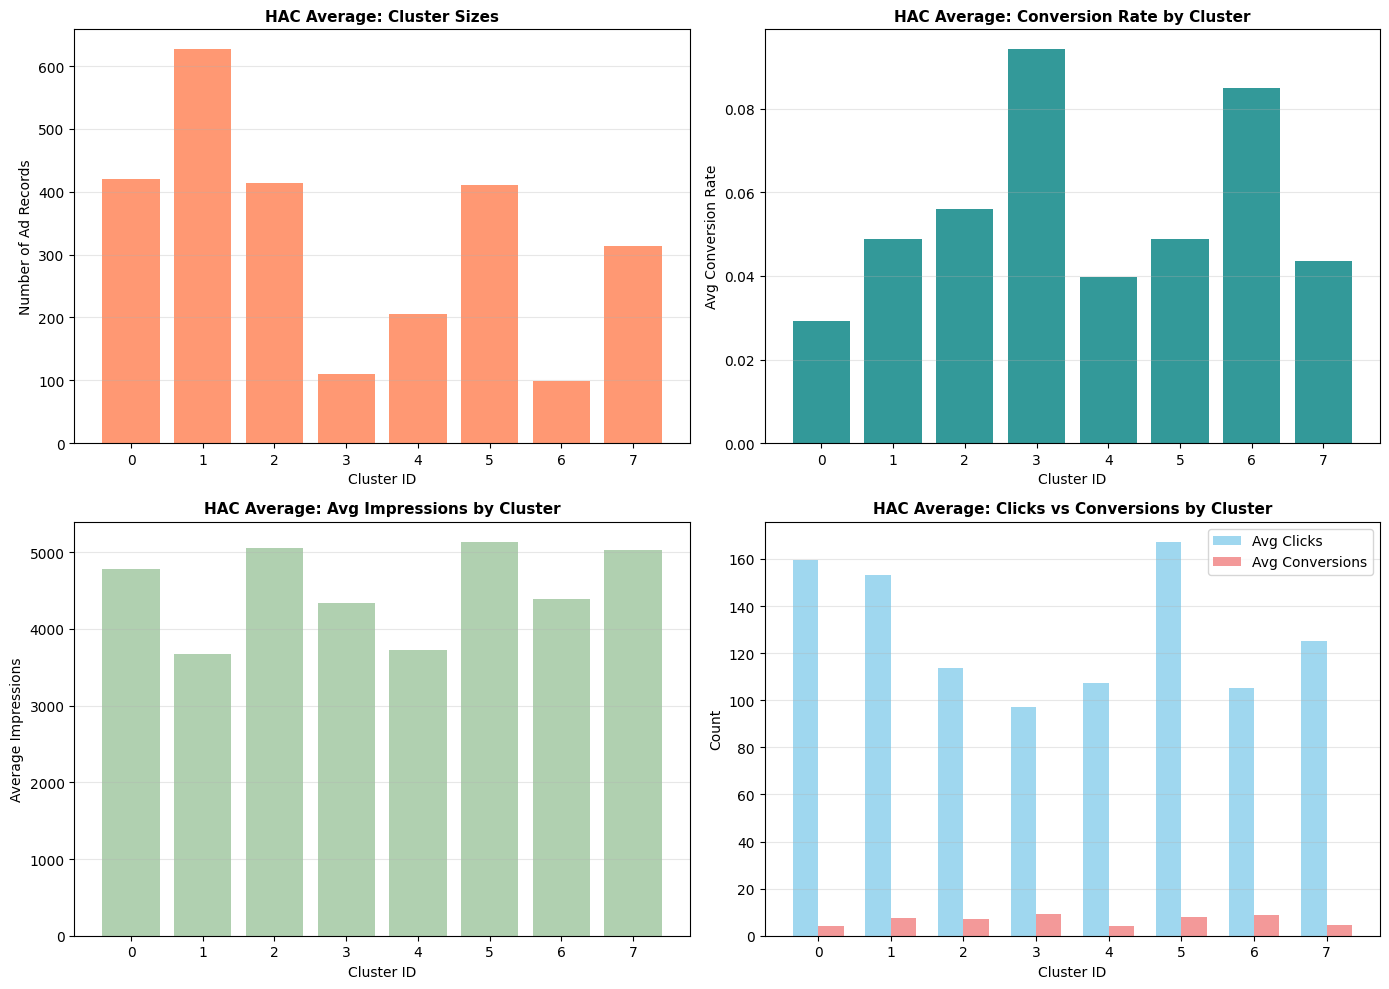

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt

print("="*70)
print("HIERARCHICAL AGGLOMERATIVE CLUSTERING (HAC) - AVERAGE LINKAGE")
print("="*70)

# Apply HAC with Average linkage
n_clusters_hac_ads = 8  # Reduced from 15 due to homogeneous data
hac_average = AgglomerativeClustering(n_clusters=n_clusters_hac_ads, linkage='average')
hac_clusters_ads = hac_average.fit_predict(X_ads_scaled)

# Add HAC clusters to dataframe
google_ads_df['HAC_Average_Cluster'] = hac_clusters_ads

print(f"\nHAC with Average Linkage applied successfully!")
print(f"  • Number of clusters: {n_clusters_hac_ads}")
print(f"  • Total ad records: {len(hac_clusters_ads)}")
print(f"  • No noise points (all records assigned to a cluster)")

# Cluster statistics
cluster_sizes_hac_ads = pd.Series(hac_clusters_ads).value_counts().sort_index()
print(f"\nCLUSTER SIZE DISTRIBUTION:")
print(f"  • Min cluster size: {cluster_sizes_hac_ads.min()}")
print(f"  • Max cluster size: {cluster_sizes_hac_ads.max()}")
print(f"  • Mean cluster size: {cluster_sizes_hac_ads.mean():.0f}")
print(f"  • Std of cluster size: {cluster_sizes_hac_ads.std():.0f}")

# Quality metrics
silhouette_hac_ads = silhouette_score(X_ads_scaled, hac_clusters_ads)
davies_bouldin_hac_ads = davies_bouldin_score(X_ads_scaled, hac_clusters_ads)
calinski_hac_ads = calinski_harabasz_score(X_ads_scaled, hac_clusters_ads)

print(f"\nCLUSTER QUALITY METRICS:")
print(f"  • Silhouette Score: {silhouette_hac_ads:.4f} (range: -1 to 1, higher is better)")
print(f"  • Davies-Bouldin Index: {davies_bouldin_hac_ads:.4f} (lower is better)")
print(f"  • Calinski-Harabasz Score: {calinski_hac_ads:.2f} (higher is better)")

# Performance analysis by cluster
print(f"\nAD PERFORMANCE ANALYSIS BY HAC CLUSTER:")
hac_ads_perf = google_ads_df.groupby('HAC_Average_Cluster').agg({
    'Clicks': 'mean',
    'Impressions': 'mean',
    'Leads': 'mean',
    'Conversions': 'mean',
    'Conversion Rate': 'mean'
}).round(3)

hac_ads_perf['Cluster_Size'] = google_ads_df.groupby('HAC_Average_Cluster').size()
hac_ads_perf = hac_ads_perf.sort_values('Conversion Rate', ascending=False)

print("\nAll Clusters by Conversion Rate:")
print(hac_ads_perf.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cluster sizes
ax1 = axes[0, 0]
cluster_sizes_sorted = pd.Series(hac_clusters_ads).value_counts().sort_index()
ax1.bar(cluster_sizes_sorted.index, cluster_sizes_sorted.values, color='coral', alpha=0.8)
ax1.set_xlabel('Cluster ID', fontsize=10)
ax1.set_ylabel('Number of Ad Records', fontsize=10)
ax1.set_title('HAC Average: Cluster Sizes', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Conversion rate by cluster
ax2 = axes[0, 1]
conv_rate_ads = google_ads_df.groupby('HAC_Average_Cluster')['Conversion Rate'].mean().sort_index()
ax2.bar(conv_rate_ads.index, conv_rate_ads.values, color='teal', alpha=0.8)
ax2.set_xlabel('Cluster ID', fontsize=10)
ax2.set_ylabel('Avg Conversion Rate', fontsize=10)
ax2.set_title('HAC Average: Conversion Rate by Cluster', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Average Impressions by Cluster
ax3 = axes[1, 0]
impressions_ads = google_ads_df.groupby('HAC_Average_Cluster')['Impressions'].mean().sort_index()
ax3.bar(impressions_ads.index, impressions_ads.values, color='darkseagreen', alpha=0.7)
ax3.set_xlabel('Cluster ID', fontsize=10)
ax3.set_ylabel('Average Impressions', fontsize=10)
ax3.set_title('HAC Average: Avg Impressions by Cluster', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Comparison: Clicks vs Conversions by Cluster
ax4 = axes[1, 1]
clicks_by_cluster = google_ads_df.groupby('HAC_Average_Cluster')['Clicks'].mean().sort_index()
conversions_by_cluster = google_ads_df.groupby('HAC_Average_Cluster')['Conversions'].mean().sort_index()
x = np.arange(len(clicks_by_cluster))
width = 0.35
ax4.bar(x - width/2, clicks_by_cluster.values, width, label='Avg Clicks', color='skyblue', alpha=0.8)
ax4.bar(x + width/2, conversions_by_cluster.values, width, label='Avg Conversions', color='lightcoral', alpha=0.8)
ax4.set_xlabel('Cluster ID', fontsize=10)
ax4.set_ylabel('Count', fontsize=10)
ax4.set_title('HAC Average: Clicks vs Conversions by Cluster', fontsize=11, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(clicks_by_cluster.index)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hac_average_ads_analysis.png', dpi=100, bbox_inches='tight')
print("\nVisualization saved as 'hac_average_ads_analysis.png'")
plt.show()

### DBSCAN for marketing_product_df

In [13]:
# Select numeric columns for clustering
numeric_cols_mp = marketing_product_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns available: {numeric_cols_mp}")

# Prepare data: fill NaN values with mean
X_mp = marketing_product_df[numeric_cols_mp].fillna(marketing_product_df[numeric_cols_mp].mean())

# Standardize the features
scaler_mp = StandardScaler()
X_mp_scaled = scaler_mp.fit_transform(X_mp)

# Run DBSCAN with same parameters for comparison
dbscan_mp = DBSCAN(eps=2.0, min_samples=5)
clusters_mp = dbscan_mp.fit_predict(X_mp_scaled)

# Add cluster labels to dataframe
marketing_product_df['DBSCAN_Cluster'] = clusters_mp

# Display results
unique_clusters_mp = set(clusters_mp) - {-1}
n_noise_mp = list(clusters_mp).count(-1)

print("\n" + "="*70)
print("DBSCAN CLUSTERING RESULTS FOR marketing_product_df")
print("="*70)
print(f"\nParameters: eps=2.0, min_samples=5")
print(f"Number of clusters: {len(unique_clusters_mp)}")
print(f"Number of noise points: {n_noise_mp} ({n_noise_mp/len(clusters_mp)*100:.1f}%)")
print(f"Number of clustered points: {len(clusters_mp) - n_noise_mp} ({(len(clusters_mp) - n_noise_mp)/len(clusters_mp)*100:.1f}%)")

print(f"\nCluster distribution:")
cluster_dist_mp = pd.Series(clusters_mp).value_counts().sort_index()
print(cluster_dist_mp)

print(f"\nTop 15 largest clusters:")
cluster_sizes_mp = pd.Series(clusters_mp).value_counts().sort_values(ascending=False)
for i, (cluster_id, size) in enumerate(cluster_sizes_mp.head(15).items(), 1):
    if cluster_id == -1:
        print(f"  {i:2}. NOISE: {size:4} points ({size/len(clusters_mp)*100:5.1f}%)")
    else:
        print(f"  {i:2}. Cluster {cluster_id:3}: {size:4} points ({size/len(clusters_mp)*100:5.1f}%)")

print(f"\nFirst 10 rows with cluster assignments:")
display_cols_mp = [col for col in marketing_product_df.columns if col in numeric_cols_mp[:5]] + ['DBSCAN_Cluster']
print(marketing_product_df[display_cols_mp].head(10))

print("\n" + "="*70)
print("CLUSTER STATISTICS")
print("="*70)
for cluster_id in sorted(unique_clusters_mp)[:10]:  # Show first 10 clusters
    cluster_data_mp = marketing_product_df[marketing_product_df['DBSCAN_Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} (n={len(cluster_data_mp)}):")
    for col in numeric_cols_mp[:5]:
        print(f"  Avg {col}: {cluster_data_mp[col].mean():.2f}")



Numeric columns available: ['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund', 'DBSCAN_Cluster']


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\pandas\core\generic.py:7406: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k



DBSCAN CLUSTERING RESULTS FOR marketing_product_df

Parameters: eps=2.0, min_samples=5
Number of clusters: 1
Number of noise points: 13 (0.1%)
Number of clustered points: 9987 (99.9%)

Cluster distribution:
-1      13
 0    9987
Name: count, dtype: int64

Top 15 largest clusters:
   1. Cluster   0: 9987 points ( 99.9%)
   2. NOISE:   13 points (  0.1%)

First 10 rows with cluster assignments:
     Budget  Clicks  Conversions  Revenue_Generated   ROI  DBSCAN_Cluster
0  41770.45    4946           73           15520.09  1.94               0
1  29900.93     570          510           30866.17  0.76               0
2  22367.45    3546          265           32585.62  1.41               0
3  29957.54    2573          781           95740.12  3.32               0
4  36277.19     818           79           81990.43  3.53               0
5  41159.74    1259          763           65792.30  0.77               0
6  32787.71    3882           29           54205.71  4.84               0
7  38372.99

C:\Users\santo\AppData\Local\Temp\ipykernel_19720\1560281467.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  marketing_product_df['DBSCAN_Cluster'] = clusters_mp


### HAC for marketing_product_df

HIERARCHICAL AGGLOMERATIVE CLUSTERING (HAC) - AVERAGE LINKAGE


C:\Users\santo\AppData\Local\Temp\ipykernel_19720\3586358300.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  marketing_product_df['HAC_Average_Cluster'] = hac_clusters_mp



HAC with Average Linkage applied successfully!
  • Number of clusters: 9
  • Total campaign-product records: 10000
  • No noise points (all records assigned to a cluster)

CLUSTER SIZE DISTRIBUTION:
  • Min cluster size: 1
  • Max cluster size: 9987
  • Mean cluster size: 1111
  • Std of cluster size: 3328

CLUSTER QUALITY METRICS:
  • Silhouette Score: 0.8424 (range: -1 to 1, higher is better)
  • Davies-Bouldin Index: 0.6819 (lower is better)
  • Calinski-Harabasz Score: 127.29 (higher is better)

CAMPAIGN-PRODUCT PERFORMANCE BY HAC CLUSTER:

All Clusters by ROI (Highest to Lowest):
                       Budget  Revenue_Generated   ROI  Conversions  Units_Sold  Customer_Satisfaction_Post_Refund  Cluster_Size
HAC_Average_Cluster                                                                                                             
8                    15348.53           92622.84  4.49        35.00       16.00                               4.00             1
4                   

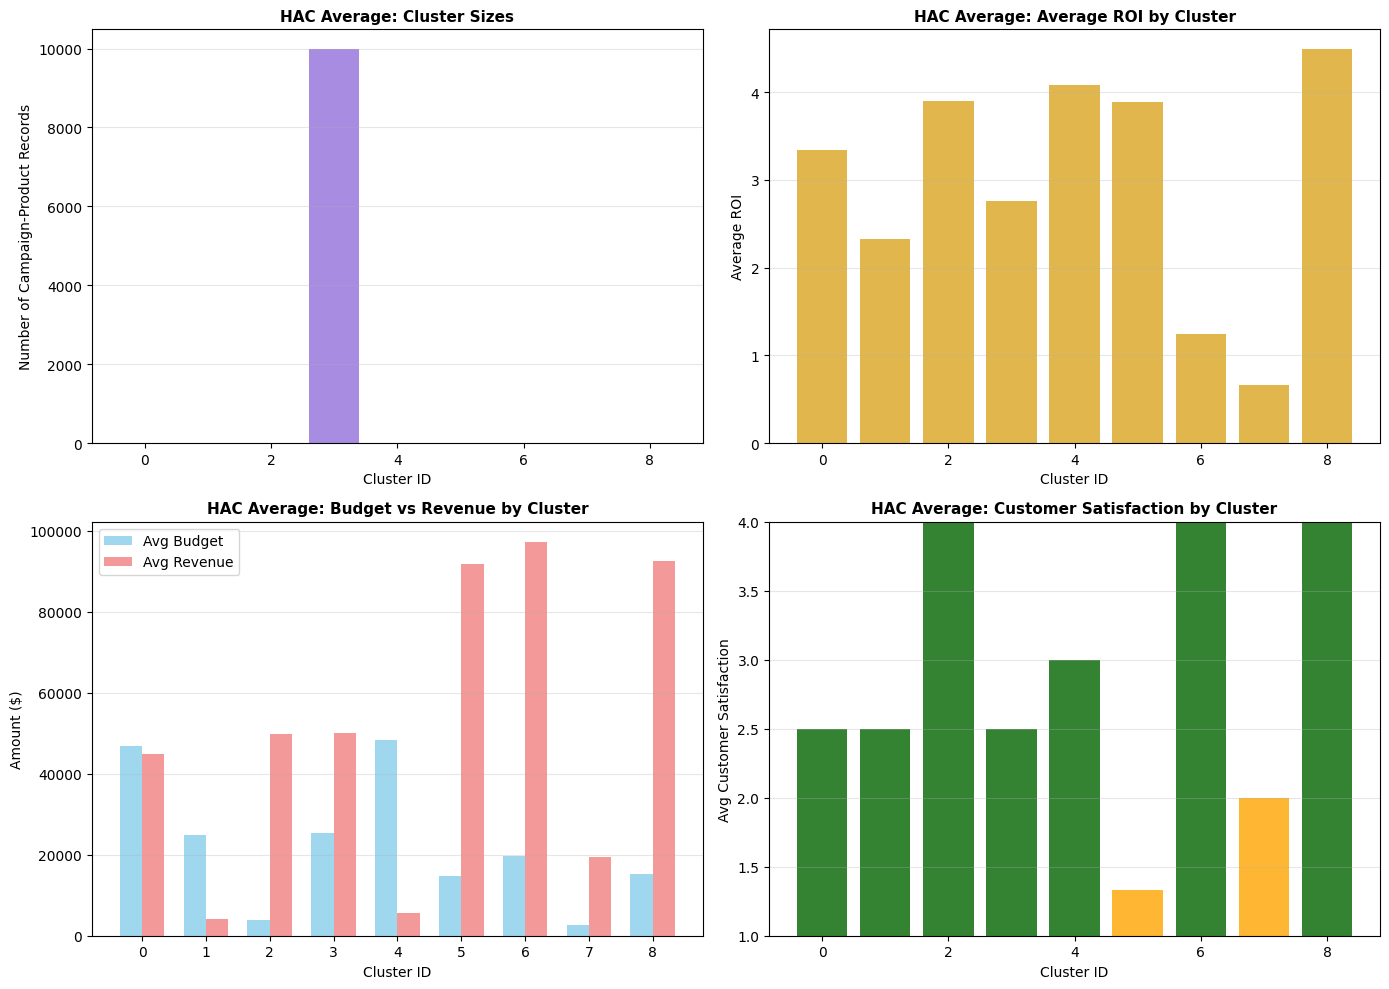

In [15]:
print("="*70)
print("HIERARCHICAL AGGLOMERATIVE CLUSTERING (HAC) - AVERAGE LINKAGE")
print("="*70)

# Apply HAC with Average linkage
n_clusters_hac_mp = 9  # 9 clusters for product-campaign segmentation
hac_average_mp = AgglomerativeClustering(n_clusters=n_clusters_hac_mp, linkage='average')
hac_clusters_mp = hac_average_mp.fit_predict(X_mp_scaled)

# Add HAC clusters to dataframe
marketing_product_df['HAC_Average_Cluster'] = hac_clusters_mp

print(f"\nHAC with Average Linkage applied successfully!")
print(f"  • Number of clusters: {n_clusters_hac_mp}")
print(f"  • Total campaign-product records: {len(hac_clusters_mp)}")
print(f"  • No noise points (all records assigned to a cluster)")

# Cluster statistics
cluster_sizes_hac_mp = pd.Series(hac_clusters_mp).value_counts().sort_index()
print(f"\nCLUSTER SIZE DISTRIBUTION:")
print(f"  • Min cluster size: {cluster_sizes_hac_mp.min()}")
print(f"  • Max cluster size: {cluster_sizes_hac_mp.max()}")
print(f"  • Mean cluster size: {cluster_sizes_hac_mp.mean():.0f}")
print(f"  • Std of cluster size: {cluster_sizes_hac_mp.std():.0f}")

# Quality metrics
silhouette_hac_mp = silhouette_score(X_mp_scaled, hac_clusters_mp)
davies_bouldin_hac_mp = davies_bouldin_score(X_mp_scaled, hac_clusters_mp)
calinski_hac_mp = calinski_harabasz_score(X_mp_scaled, hac_clusters_mp)

print(f"\nCLUSTER QUALITY METRICS:")
print(f"  • Silhouette Score: {silhouette_hac_mp:.4f} (range: -1 to 1, higher is better)")
print(f"  • Davies-Bouldin Index: {davies_bouldin_hac_mp:.4f} (lower is better)")
print(f"  • Calinski-Harabasz Score: {calinski_hac_mp:.2f} (higher is better)")

# Campaign-Product performance analysis
print(f"\nCAMPAIGN-PRODUCT PERFORMANCE BY HAC CLUSTER:")
hac_mp_perf = marketing_product_df.groupby('HAC_Average_Cluster').agg({
    'Budget': 'mean',
    'Revenue_Generated': 'mean',
    'ROI': 'mean',
    'Conversions': 'mean',
    'Units_Sold': 'mean',
    'Customer_Satisfaction_Post_Refund': 'mean'
}).round(2)

hac_mp_perf['Cluster_Size'] = marketing_product_df.groupby('HAC_Average_Cluster').size()
hac_mp_perf = hac_mp_perf.sort_values('ROI', ascending=False)

print("\nAll Clusters by ROI (Highest to Lowest):")
print(hac_mp_perf.to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cluster sizes
ax1 = axes[0, 0]
cluster_sizes_sorted_mp = pd.Series(hac_clusters_mp).value_counts().sort_index()
ax1.bar(cluster_sizes_sorted_mp.index, cluster_sizes_sorted_mp.values, color='mediumpurple', alpha=0.8)
ax1.set_xlabel('Cluster ID', fontsize=10)
ax1.set_ylabel('Number of Campaign-Product Records', fontsize=10)
ax1.set_title('HAC Average: Cluster Sizes', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. ROI by cluster
ax2 = axes[0, 1]
roi_by_cluster = marketing_product_df.groupby('HAC_Average_Cluster')['ROI'].mean().sort_index()
ax2.bar(roi_by_cluster.index, roi_by_cluster.values, color='goldenrod', alpha=0.8)
ax2.set_xlabel('Cluster ID', fontsize=10)
ax2.set_ylabel('Average ROI', fontsize=10)
ax2.set_title('HAC Average: Average ROI by Cluster', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Revenue vs Budget by Cluster
ax3 = axes[1, 0]
budget_by_cluster = marketing_product_df.groupby('HAC_Average_Cluster')['Budget'].mean().sort_index()
revenue_by_cluster = marketing_product_df.groupby('HAC_Average_Cluster')['Revenue_Generated'].mean().sort_index()
x_pos = np.arange(len(budget_by_cluster))
width = 0.35
ax3.bar(x_pos - width/2, budget_by_cluster.values, width, label='Avg Budget', color='skyblue', alpha=0.8)
ax3.bar(x_pos + width/2, revenue_by_cluster.values, width, label='Avg Revenue', color='lightcoral', alpha=0.8)
ax3.set_xlabel('Cluster ID', fontsize=10)
ax3.set_ylabel('Amount ($)', fontsize=10)
ax3.set_title('HAC Average: Budget vs Revenue by Cluster', fontsize=11, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(budget_by_cluster.index)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Customer Satisfaction by Cluster
ax4 = axes[1, 1]
satisfaction_by_cluster = marketing_product_df.groupby('HAC_Average_Cluster')['Customer_Satisfaction_Post_Refund'].mean().sort_index()
colors_satisfaction = ['darkgreen' if x >= 2.5 else 'orange' for x in satisfaction_by_cluster.values]
ax4.bar(satisfaction_by_cluster.index, satisfaction_by_cluster.values, color=colors_satisfaction, alpha=0.8)
ax4.set_xlabel('Cluster ID', fontsize=10)
ax4.set_ylabel('Avg Customer Satisfaction', fontsize=10)
ax4.set_title('HAC Average: Customer Satisfaction by Cluster', fontsize=11, fontweight='bold')
ax4.set_ylim([1, 4])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hac_average_mp_analysis.png', dpi=100, bbox_inches='tight')
print("\nVisualization saved as 'hac_average_mp_analysis.png'")
plt.show()